<a href="https://colab.research.google.com/github/Harold-dev-code/challenge_Telecom-X_parte_uno/blob/main/challenge_Telecom_X_parte_uno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\huge \text{📊challenge_Telecom-X_parte_uno}$$


Este proyecto forma parte del desafío de formación en Data Science para la empresa Telecom X. El objetivo principal es analizar los factores que influyen en la pérdida de clientes (Churn) para transformar datos crudos en información estratégica que permita mejorar la retención de los clientes.

#Etapa 1: Extract (Extracción) 📥

En este paso conectamos con la fuente de datos (GitHub) para obtener el archivo JSON con la información de los clientes de Telecom X y traerlo a nuestro entorno de trabajo.

In [70]:
import requests
import pandas as pd

# 1. Extraemos los datos con requests
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json() # Aquí tenemos la lista de diccionarios pura
# df = pd.DataFrame(data): Crea una tabla "bruta". Si hay diccionarios dentro, los deja ahí apretados en una sola celda.

# 2. Mejor "Aplanamos" los datos anidados
# json_normalize convierte los diccionarios internos en columnas independientes
df = pd.json_normalize(data)

# 3. Verificamos el resultado
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


**📊 Diccionario de Datos: Telecom X**


**1. Identificación y Objetivo**

**(Target)customerID**: Identificador único alfanumérico para cada cliente.

**Churn (Abandono)**: Nuestra variable objetivo. Indica si el cliente se dio de baja del servicio en el último mes (Yes o No).

**2. Perfil Demográfico (customer)**

**gender (Género)**: Sexo biológico del cliente (Male/Hombre o Female/Mujer).

**SeniorCitizen (Adulto Mayor)**: Variable binaria que indica si el cliente es una persona mayor (1) o no (0).

**Partner (Pareja)**: Indica si el cliente tiene una relación de pareja estable.

**Dependents (Dependientes)**: Indica si el cliente tiene personas a su cargo (hijos, padres, etc.).

**tenure (Antigüedad)**: Tiempo total en meses que el cliente ha estado con la compañía.

**3. Servicios de Conectividad (phone & internet)**

**PhoneService**: Si el cliente tiene contratada una línea telefónica.

**MultipleLines**: Indica si tiene más de una línea telefónica activa.

**InternetService**: Tipo de conexión (DSL, Fiber optic / Fibra óptica, o No).

**Servicios Digitales Adicionales**: Incluye seguridad en línea, respaldo en la nube, protección de dispositivos y soporte técnico (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport).

**Servicios de Entretenimiento**: Si el cliente consume televisión por internet o películas (StreamingTV, StreamingMovies).

**4. Información Financiera (account)**

**Contract (Contrato)**: Duración del compromiso legal (Mes a mes, Un año, Dos años).

**PaperlessBilling**: Si el cliente optó por facturación electrónica (sin papel).

**PaymentMethod (Método de Pago)**: Cómo paga el cliente (Transferencia bancaria, Tarjeta de crédito, Cheque electrónico, Cheque enviado por correo).

**Charges.Monthly (Cargos Mensuales)**: El monto que se le factura al cliente de forma recurrente cada mes.

**Charges.Total (Cargos Totales)**: La suma histórica de todo lo que el cliente ha pagado a la empresa hasta hoy.

**🔎 Revisión**<br>
<br>
Necesitamos saber qué tan "sanos" están los datos de Telecom X.  una revisión exhaustiva de los datos siempre es buena

In [71]:
#Chequeamos los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

En la columna número 20: account.Charges.Total, Dice que es tipo object (texto).

Debería ser float64 (decimal) por que esto es dinero, igual que los cargos mensuales (account.Charges.Monthly).

Probablemente hay algunos espacios en blanco o caracteres especiales en esa columna que engañaron a Pandas haciéndole creer que es texto. Si no arreglamos esto, no podrás sumar ni sacar promedios del gasto total.

**Valores Duplicados**

In [72]:
# DUPLICADOS
df.duplicated().sum()

np.int64(0)

No presentamos registros duplicados

**Datos nulos**

El reporte dice que todas las columnas tienen 7267 non-null, A simple vista parece que no faltan datos. pero lo revisaremos a fondo.A veces, en lugar de dejar el espacio vacío (nulo), los sistemas ponen un texto que dice " " (un espacio) o "None".Para Python eso cuenta como "información", pero para nosotros sigue siendo un dato faltante.

In [73]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


El siguiente código realiza una auditoría integral de calidad de datos para cada columna en el DataFrame df. Para cada columna, calcula los valores únicos, la cantidad de nulos técnicos (NaN), los espacios en blanco o cadenas vacías, y los valores cero (0). Luego, imprime un encabezado para la columna, seguido de alertas si detecta problemas como valores nulos o espacios vacíos. También proporciona un aviso si encuentra valores cero, especialmente si la columna no es un ID. Finalmente, resume el contenido mostrando los valores únicos si son menos de 30, o indicando alta variabilidad si hay más de 30 valores distintos.



**Auditoria Integral**

In [74]:
import numpy as np

print("🚀 INICIANDO AUDITORÍA INTEGRAL DE CALIDAD DE DATOS\n")
print("-" * 70)

for col in df.columns:
    # 1. Cálculos de limpieza básicos
    valores_unicos = df[col].nunique()
    nulos_nan = df[col].isnull().sum()

    # Detectar espacios en blanco (convertimos a string para asegurar el  metodo .strip.strip())
    #Su función es eliminar los espacios en blanco iniciales y finales de cada cadena en la columna.
    #Por ejemplo:' hola ' se convierte en 'hola' ; ' ' (solo espacios) se convierte en '' (cadena vacía)
    #'' (cadena ya vacía) sigue siendo ''
    espacios_fantasma = (df[col].astype(str).str.strip() == '').sum()

    # Detectar ceros (solo si la columna es numérica o parece numérica)
    #pd.to_numeric(..., errors='coerce') intenta convertir los datos de cada columna a tipo numérico,Si encuentra valores que no puede convertir,
    #los reemplaza con NaN (Not a Number) en lugar de generar un error, lo que es ideal para manejar datos mixtos.
    try:
        valores_cero = (pd.to_numeric(df[col], errors='coerce') == 0).sum()
    except:
        valores_cero = 0

    # 2. Encabezado de la Columna
    print(f"📊 COLUMNA: {col.upper()} ({df[col].dtype})")

    # 3. Bloque de ALERTAS (Solo aparecen si hay problemas)
    hay_problemas = False

    if nulos_nan > 0:
        print(f"   🚨 ALERTA: {nulos_nan} valores NULOS (NaN) detectados.")
        hay_problemas = True

    if espacios_fantasma > 0:
        print(f"   ⚠️ ALERTA: {espacios_fantasma} celdas con ESPACIOS VACÍOS (' ') detectadas.")
        hay_problemas = True

    if valores_cero > 0 and "ID" not in col.upper():
        print(f"   💡 AVISO: {valores_cero} valores en CERO (0) encontrados.")
        # No marcamos hay_problemas como True aquí porque el 0 puede ser válido

    if not hay_problemas:
        print("   ✅ Sin problemas críticos de integridad.")

    # 4. Resumen de contenido
    if valores_unicos < 30:
        print(f"   📝 Valores únicos ({valores_unicos}): {df[col].unique()}")
    else:
        print(f"   📈 Alta variabilidad: {valores_unicos} valores distintos.")

    print("-" * 70)

🚀 INICIANDO AUDITORÍA INTEGRAL DE CALIDAD DE DATOS

----------------------------------------------------------------------
📊 COLUMNA: CUSTOMERID (object)
   ✅ Sin problemas críticos de integridad.
   📈 Alta variabilidad: 7267 valores distintos.
----------------------------------------------------------------------
📊 COLUMNA: CHURN (object)
   ⚠️ ALERTA: 224 celdas con ESPACIOS VACÍOS (' ') detectadas.
   📝 Valores únicos (3): ['No' 'Yes' '']
----------------------------------------------------------------------
📊 COLUMNA: CUSTOMER.GENDER (object)
   ✅ Sin problemas críticos de integridad.
   📝 Valores únicos (2): ['Female' 'Male']
----------------------------------------------------------------------
📊 COLUMNA: CUSTOMER.SENIORCITIZEN (int64)
   💡 AVISO: 6085 valores en CERO (0) encontrados.
   ✅ Sin problemas críticos de integridad.
   📝 Valores únicos (2): [0 1]
----------------------------------------------------------------------
📊 COLUMNA: CUSTOMER.PARTNER (object)
   ✅ Sin problem

Las columnas con las ⚠️ ALERTAS presentan espacios vacios detectados:  
- ACCOUNT.CHARGES.TOTAL con 11 celdas con (' ')
- CHURN con 224 celdas con (' ')

Las columnas que aparecen con el icono del bombillo (💡) en el reporte no representan necesariamente un error, sino un aviso informativo sobre la presencia de valores en cero (0).

- CUSTOMER.SENIORCITIZEN (6085 valores en cero):

Aquí el cero es totalmente normal. En esta columna, 0 significa que el cliente no es un adulto mayor y 1 que sí lo es. Que la mayoría sean 0 solo indica que la mayor parte de tus clientes son personas jóvenes o de mediana edad.

- CUSTOMER.TENURE (11 valores en cero):

Esto también tiene una explicación lógica muy interesante. Un tenure (antigüedad) de 0 meses significa que son clientes nuevos que acaban de contratar el servicio y aún no cumplen su primer mes.

Dato curioso: hay 11 valores en cero en antigüedad y casualmente hay 11 espacios vacíos en Charges.Total? Esto confirma que esos espacios vacíos no son un error aleatorio: son clientes tan nuevos que aún no se les ha generado su primera factura total.



**Conclusión**

Nuestra revisión exhaustiva de los datos ha revelado puntos clave para las transformaciones que son fundamentales para garantizar la fiabilidad y utilidad de nuestros datos en las etapas posteriores del análisis.

1.  **Columna `Churn`**: Se encontraron 224 celdas con espacios vacíos. Estos valores  seran eliminados para asegurar la integridad de nuestro modelo predictivo.

2.  **Columna `account.Charges.Total`**: Identificamos 11 celdas con espacios vacíos y notamos que la columna está clasificada como tipo `object` (texto) en lugar de un tipo numérico (decimal). Este es un problema crítico, ya que impide cálculos financieros precisos. Además, la coincidencia de 11 espacios vacíos aquí con 11 clientes con 'tenure' (antigüedad) de 0 sugiere que son clientes tan nuevos que aún no tienen cargos totales registrados. estos ultimos los convertiremos y seran tratados con el valor de 0 para convertir la columna a un tipo de dato numérico (`float`).




#Etapa 2: Transform (Transformación) ⚙️
Aquí limpiaremos los datos. Buscaremos valores nulos, corregiremos tipos de datos y prepararemos las columnas para que el análisis sea preciso.

**Columna Churn**<BR>
eliminar 224 celdas con espacios vacios

In [75]:
df[df['Churn'].str.strip() == ''].shape[0] #Verifica espacios vacíos o son cadenas vacías

224

In [76]:
df = df[df['Churn'] != ' '] # Crea un nuevo DataFrame df (sobrescribiendo el anterior) solo elimina celdas que son exactamente un espacio en blanco (' ')

print("Número de filas después de eliminar las vacías en 'Churn':", len(df))


Número de filas después de eliminar las vacías en 'Churn': 7267


In [77]:
df[df['Churn'].str.strip() == ''].shape[0]

224

In [78]:
df= df[df['Churn'].str.strip() != ''] #Para eliminar cualquier tipo de espacio en blanco (incluyendo cadenas vacías '' o múltiples espacios como ' ')
print("Número de filas después de eliminar las vacías en 'Churn':", len(df))

Número de filas después de eliminar las vacías en 'Churn': 7043


In [79]:
# Verifica la cantidad de filas en la columna 'Churn' que aún tienen espacios vacíos o son cadenas vacías
df[df['Churn'].str.strip() == ''].shape[0]

0

**Columna account.Charges.Total** <br>
- convertir la columna a un tipo de dato numérico

In [80]:
#esta línea transforma la columna de object (texto) a un tipo numérico,
#haciendo que los valores que antes eran cadenas vacías o no numéricas ahora sean NaN,
# preparándolas para ser rellenados con 0 como se hace en el siguiente paso.


df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')


In [81]:
#verificamos cambio de tipo de dato
df['account.Charges.Total'].dtype

dtype('float64')

In [82]:
#revisamos y aparecen los 11 datos que eran vacios ahora son nulos
df.isnull().sum()


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [83]:
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0) # Reemplazamos los valores NaN con 0 en la columna de cargos totales

In [84]:
# revisamos nuevamente, encontramos que ya no ay nulos en account.Charges.Total y nos confirma que ya quedaron trasnformados para ser tratados con le valor de 0 por ser clientes que llevan menos de un mes
df.isnull().sum()



,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [85]:
df[df['account.Charges.Monthly'] == 0].shape[0]

0

In [86]:
min_monthly_charge = df['account.Charges.Monthly'].min()
max_monthly_charge = df['account.Charges.Monthly'].max()

print(f"El valor mínimo de 'account.Charges.Monthly' es: {min_monthly_charge}")
print(f"El valor máximo de 'account.Charges.Monthly' es: {max_monthly_charge}")

El valor mínimo de 'account.Charges.Monthly' es: 18.25
El valor máximo de 'account.Charges.Monthly' es: 118.75


**Nota de Auditoría**: Se identificaron 11 clientes con antigüedad (tenure) de 0 meses. Estos registros presentan espacios vacíos en Charges.Total debido a que aún no han cerrado su primer ciclo de facturación. No obstante, muestran valores positivos en Charges.Monthly, es normal que el cargo mensual sea mayor a cero (entre 18.25 y 118.75 según los filtros) porque este campo refleja la tarifa del plan contratado que se les facturará a futuro por ser clientes nuevos.

#Etapa 3: Load (Carga) 💾

Una vez que los datos están "curados" y listos, los guardamos en una estructura final o archivo para que el equipo de Data Science pueda usarlos en sus modelos.

## 1. Analisis Descriptiva

In [87]:
# Seleccionamos las columnas numéricas para el análisis descriptivo
numeric_cols = ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# Calculamos las estadísticas descriptivas estándar
described_stats = df[numeric_cols].describe()

# Calculamos la mediana por separado, ya que describe() no la incluye directamente
median_stats = df[numeric_cols].median().to_frame(name='median')

# Combinamos las estadísticas descriptivas y la mediana
full_descriptive_stats = pd.concat([described_stats, median_stats.T])

# Definimos el formato para las columnas monetarias
format_dict = {
    'account.Charges.Monthly': '${:,.2f}',
    'account.Charges.Total': '${:,.2f}',
}

# Formateamos todas las celdas a un máximo de 2 decimales y aplicamos el formato de moneda donde corresponda
formatted_descriptive_stats = full_descriptive_stats.style.format('{:,.2f}') \
                                                      .format(format_dict, subset=pd.IndexSlice[:, ['account.Charges.Monthly', 'account.Charges.Total']])

print("Análisis Descriptivo Completo de Datos Numéricos:")
display(formatted_descriptive_stats)

Análisis Descriptivo Completo de Datos Numéricos:


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,"7,043.00","7,043.00","$7,043.00","$7,043.00"
mean,0.16,32.37,$64.76,"$2,279.73"
std,0.37,24.56,$30.09,"$2,266.79"
min,0.00,0.00,$18.25,$0.00
25%,0.00,9.00,$35.50,$398.55
50%,0.00,29.00,$70.35,"$1,394.55"
75%,0.00,55.00,$89.85,"$3,786.60"
max,1.00,72.00,$118.75,"$8,684.80"
median,0.00,29.00,$70.35,"$1,394.55"


### Hallazgos del Análisis Descriptivo

El análisis descriptivo de las columnas numéricas clave ha revelado insights importantes sobre la base de clientes de Telecom X:

**Antigüedad de Clientes (`customer.tenure`):** La media (32.37) es mayor que la mediana (29), lo que indica que tenemos un grupo importante de clientes muy leales (cercanos a los 72 meses) que "empujan" el promedio hacia arriba.

* **Fidelidad:** El rango de permanencia va de 0 a 72 meses, lo que muestra una empresa con al menos 6 años en el mercado.                                                           

**Cargos Mensuales (`account.Charges.Monthly`):** Los cargos oscilan en un rango amplio, desde un mínimo de 💲18.25 hasta un máximo de 💲118.75, lo que confirma una oferta comercial segmentada para distintos niveles de consumo.

* **Concentración de Clientes:** La mediana (💲70.35) se sitúa por encima del promedio (💲64.76). Esto sugiere que el volumen principal de la cartera de Telecom X está suscrito a planes de rango medio-alto, mientras que los planes básicos (cercanos al mínimo) son menos frecuentes pero impactan el promedio general.

* **Diversidad de la Oferta:** La desviación estándar (💲30.09) representa casi el 46% del valor promedio, lo que evidencia una alta variabilidad. Esto se traduce en una estrategia de productos diversificada, con paquetes que probablemente escalan significativamente al añadir servicios de valor agregado (como fibra óptica o streaming).

**Cargos Totales (`account.Charges.Total`):** El cargo total promedio es de 💲2,279.73, pero la mediana es considerablemente menor, 💲1,394.55. Esta diferencia indica que hay un grupo de clientes con cargos totales muy elevados que elevan el promedio, mientras que la mayoría tiene cargos totales más modestos. La desviación estándar es muy alta (💲2,266.79), lo cual es esperado dada la influencia de la antigüedad y los cargos mensuales. El valor mínimo de 💲0.00 se corresponde con los clientes más nuevos.

**Adultos Mayores (`customer.SeniorCitizen`):** Aproximadamente el 16% de la base de clientes son adultos mayores (representados por un valor de 1), mientras que la gran mayoría es joven o de mediana edad (valor de 0).

## 2. Distribución de evasión
En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utilizamos gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

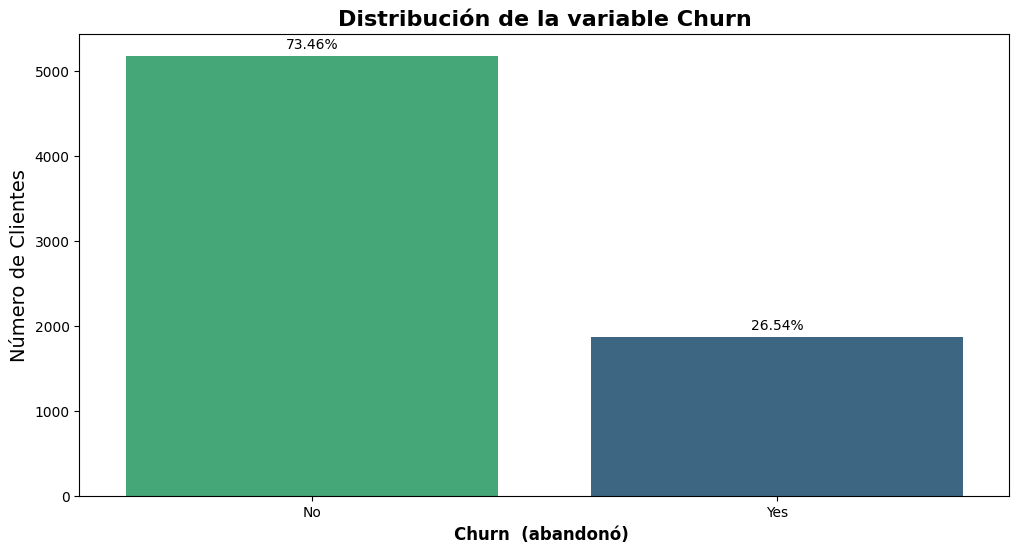

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la cantidad de clientes por categoría de Churn
churn_counts = df['Churn'].value_counts()

# Calculamos los porcentajes
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

# Creamos el gráfico de barras
plt.figure(figsize=(12, 6))
sns.countplot(x='Churn', data=df, palette='viridis_r', hue='Churn', legend=False)
plt.title('Distribución de la variable Churn', fontsize=16, weight = 'bold')
plt.xlabel('Churn  (abandonó) ', fontsize=12, weight = 'bold')
plt.ylabel('Número de Clientes', fontsize=14,  )

# Agregamos los porcentajes encima de cada barra
for index, row in enumerate(churn_counts.index):
    plt.text(index, churn_counts.loc[row] + 50, f'{churn_percentages.loc[row]:.2f}%',
             color='black', ha="center", va='bottom', fontsize=10)

plt.show()



In [89]:
print("Número de clientes por Churn:")
print(churn_counts)
print("\nPorcentaje de clientes por Churn:")
print(churn_percentages)

Número de clientes por Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de clientes por Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 3. Recuento de evasión por variables categóricas
Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

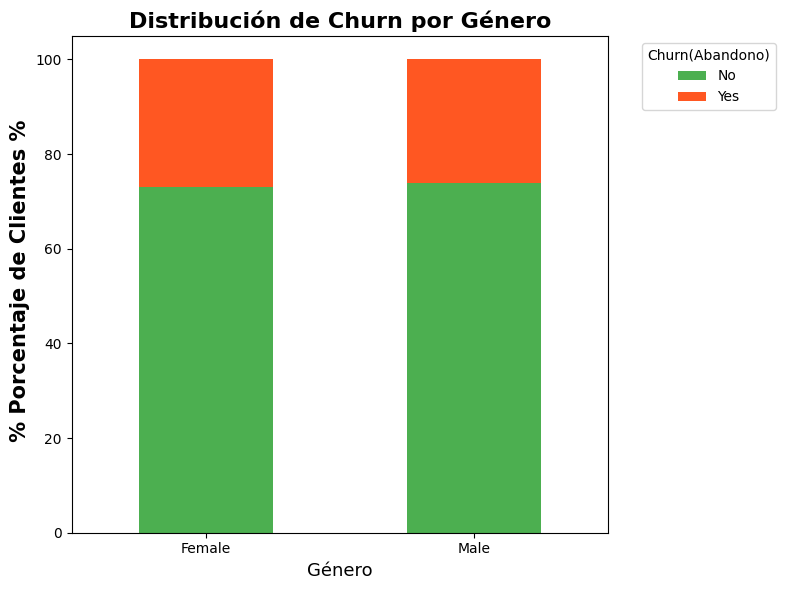

In [90]:


# Calculamos la distribución de Churn por género
churn_gender = df.groupby(['customer.gender', 'Churn']).size().unstack(fill_value=0)

# Calculamos los porcentajes dentro de cada género
churn_gender_percentage = churn_gender.apply(lambda x: x / x.sum() * 100, axis=1)

# Creamos el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(8, 6))
churn_gender_percentage.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF5722'], ax=ax)

plt.title('Distribución de Churn por Género', fontsize=16, weight = 'bold' )
plt.xlabel('Género', fontsize=13,)
plt.ylabel(' % Porcentaje de Clientes %', fontsize=15, weight = 'bold')
plt.xticks(rotation=0)
plt.legend(title='Churn(Abandono)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [91]:
print("Distribución de Churn por Género (Conteo):")
display(churn_gender)

print("\nDistribución de Churn por Género (Porcentaje):")
display(churn_gender_percentage)

Distribución de Churn por Género (Conteo):


Churn,No,Yes
customer.gender,,
Female,2549,939
Male,2625,930



Distribución de Churn por Género (Porcentaje):


Churn,No,Yes
customer.gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


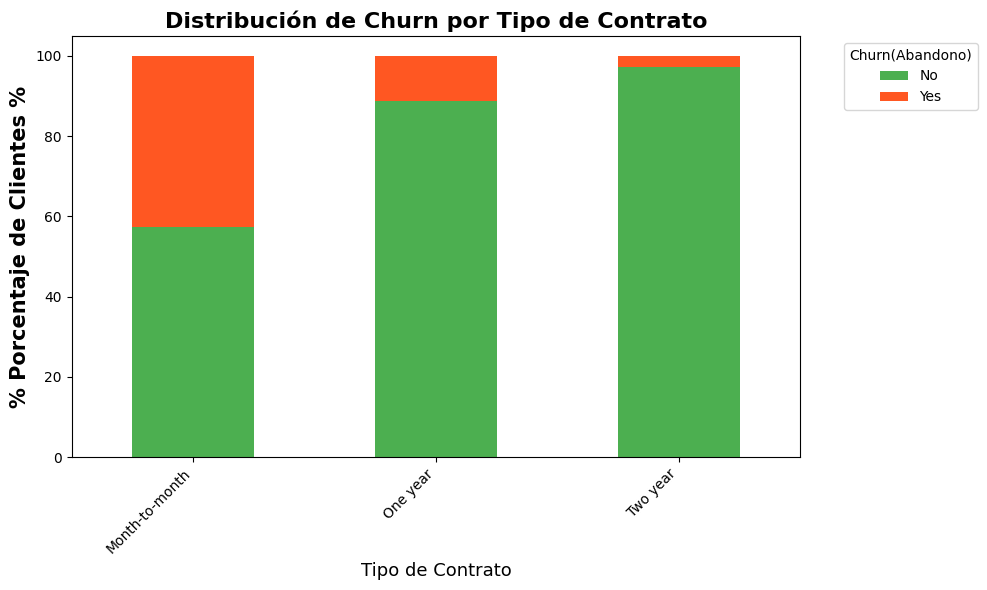

Distribución de Churn por Tipo de Contrato (Conteo):


Churn,No,Yes
account.Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48



Distribución de Churn por Tipo de Contrato (Porcentaje):


Churn,No,Yes
account.Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [92]:


# Calculamos la distribución de Churn por tipo de contrato
churn_contract = df.groupby(['account.Contract', 'Churn']).size().unstack(fill_value=0)

# Calculamos los porcentajes dentro de cada tipo de contrato
churn_contract_percentage = churn_contract.apply(lambda x: x / x.sum() * 100, axis=1)

# Creamos el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(10, 6))
churn_contract_percentage.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF5722'], ax=ax)

plt.title('Distribución de Churn por Tipo de Contrato', fontsize=16, weight = 'bold')
plt.xlabel('Tipo de Contrato', fontsize=13)
plt.ylabel('% Porcentaje de Clientes %', fontsize=15, weight = 'bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn(Abandono)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Distribución de Churn por Tipo de Contrato (Conteo):")
display(churn_contract)

print("\nDistribución de Churn por Tipo de Contrato (Porcentaje):")
display(churn_contract_percentage)

In [93]:
import plotly.express as px


# Calculamos la distribución de Churn por método de pago
churn_payment_method = df.groupby(['account.PaymentMethod', 'Churn']).size().unstack(fill_value=0)

# Calculamos los porcentajes dentro de cada método de pago
churn_payment_method_percentage = churn_payment_method.apply(lambda x: x / x.sum() * 100, axis=1).reset_index()

# 'Derretimos' el DataFrame para que Plotly pueda apilar los porcentajes correctamente
churn_payment_method_melted = churn_payment_method_percentage.melt(id_vars='account.PaymentMethod', var_name='Churn_Status', value_name='Percentage')

# Creamos el gráfico de barras apiladas con Plotly Express
fig = px.bar(churn_payment_method_melted,
             x='account.PaymentMethod',
             y='Percentage',
             color='Churn_Status',
             title='Distribución de Churn por Método de Pago',
             labels={'account.PaymentMethod': 'Método de Pago', 'Percentage': '% Porcentaje de Clientes %'},
             color_discrete_map={'No': '#4CAF50', 'Yes': '#FF5722'},
             height=500)

fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    xaxis_title_font_size=16, # Tamaño de fuente para el título del eje X (Método de Pago)
    xaxis_tickfont_size=14,   # Tamaño de fuente para las etiquetas de los ticks del eje X (los nombres de los métodos)
    yaxis_title_font_size=20,
    yaxis_title_font_weight='bold',
    xaxis_title_font_weight='bold',
    xaxis_tickangle=-45,
    legend_title_text='Churn(Abandono)'
)

fig.show()

print("Distribución de Churn por Método de Pago (Conteo):")
display(churn_payment_method)

print("\nDistribución de Churn por Método de Pago (Porcentaje):")
display(churn_payment_method_percentage.set_index('account.PaymentMethod'))

Distribución de Churn por Método de Pago (Conteo):


Churn,No,Yes
account.PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308



Distribución de Churn por Método de Pago (Porcentaje):


Churn,No,Yes
account.PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [94]:
import plotly.express as px

# Creamos el histograma de Churn por tipo de servicio de internet
fig = px.histogram(df,
                   x='internet.InternetService',
                   color='Churn',
                   text_auto=True, # Muestra el valor de cada barra automáticamente
                   barmode='group', # Agrupa las barras por Churn en lugar de apilarlas
                   title='Distribución de Churn por Tipo de Servicio de Internet',
                   labels={'internet.InternetService': 'Tipo de Servicio de Internet', 'count': 'Número de Clientes'},
                   color_discrete_map={'No': '#4CAF50', 'Yes': '#FF5722'},
                   height=500)

fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    xaxis_title_font_size=16,
    xaxis_tickfont_size=14,
    yaxis_title_font_size=20,
    yaxis_title_font_weight='bold',
    xaxis_tickangle=-45,
    legend_title_text='Churn(Abandono)'
)

fig.show()

# También podemos imprimir los conteos y porcentajes para un análisis más detallado
churn_internet_service = df.groupby(['internet.InternetService', 'Churn']).size().unstack(fill_value=0)
churn_internet_service_percentage = churn_internet_service.apply(lambda x: x / x.sum() * 100, axis=1)

print("\nDistribución de Churn por Tipo de Servicio de Internet (Conteo):")
display(churn_internet_service)

print("\nDistribución de Churn por Tipo de Servicio de Internet (Porcentaje):")
display(churn_internet_service_percentage)


Distribución de Churn por Tipo de Servicio de Internet (Conteo):


Churn,No,Yes
internet.InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113



Distribución de Churn por Tipo de Servicio de Internet (Porcentaje):


Churn,No,Yes
internet.InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [95]:
import plotly.express as px
import pandas as pd

# Calculamos la distribución de Churn por servicio telefónico
churn_phone_service = df.groupby(['phone.PhoneService', 'Churn']).size().unstack(fill_value=0)

# Calculamos los porcentajes dentro de cada categoría de servicio telefónico
churn_phone_service_percentage = churn_phone_service.apply(lambda x: x / x.sum() * 100, axis=1).reset_index()

# 'Derretimos' el DataFrame para que Plotly pueda apilar los porcentajes correctamente
churn_phone_service_melted = churn_phone_service_percentage.melt(id_vars='phone.PhoneService', var_name='Churn_Status', value_name='Percentage')

# Creamos el gráfico de barras apiladas con Plotly Express
fig = px.bar(churn_phone_service_melted,
             x='phone.PhoneService',
             y='Percentage',
             color='Churn_Status',
             title='Distribución de Churn por Servicio Telefónico',
             labels={'phone.PhoneService': 'Servicio Telefónico', 'Percentage': '% Porcentaje de Clientes %'},
             color_discrete_map={'No': '#4CAF50', 'Yes': '#FF5722'},
             height=500)

fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    xaxis_title_font_size=16,
    xaxis_tickfont_size=14,
    yaxis_title_font_size=20,
    yaxis_title_font_weight='bold',
    xaxis_tickangle=0, # No se necesita rotación para 2 categorías
    legend_title_text='Churn(Abandono)'
)

fig.show()

print("Distribución de Churn por Servicio Telefónico (Conteo):")
display(churn_phone_service)

print("\nDistribución de Churn por Servicio Telefónico (Porcentaje):")
display(churn_phone_service_percentage.set_index('phone.PhoneService'))

Distribución de Churn por Servicio Telefónico (Conteo):


Churn,No,Yes
phone.PhoneService,,
No,512,170
Yes,4662,1699



Distribución de Churn por Servicio Telefónico (Porcentaje):


Churn,No,Yes
phone.PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


## 4. Conteo de evasión por variables numéricas
En este paso, se explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.



In [96]:
# Crea el histograma interactivo
fig = px.histogram(df,
                   x='customer.tenure',
                   color='Churn',
                   barmode='group',
                   title='Distribución de Churn por Antigüedad del Cliente (Tenure)',
                   labels={'customer.tenure': 'Antigüedad del Cliente (Meses)', 'count': 'Número de Clientes'},
                   color_discrete_map={'No': '#4CAF50', 'Yes': '#FF5722'},
                   height=500)

# Actualiza el diseño para una mejor legibilidad
fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    xaxis_title_font_size=16,
    yaxis_title_font_size=20,
    yaxis_title_font_weight='bold',
    legend_title_text='Churn (Abandono)'
)

fig.show()

### Hallazgos de Churn por Antigüedad del Cliente (Tenure)



*   **Mayor Churn en Clientes Nuevos:** Los clientes con **baja antigüedad** (especialmente en los primeros meses) muestran una propensión significativamente mayor a abandonar el servicio. Las barras naranjas (Churn = Sí) son más prominentes en el lado izquierdo del gráfico.
*   **Fidelización con el Tiempo:** A medida que la antigüedad del cliente aumenta, la tasa de abandono disminuye drásticamente. Los clientes con **alta antigüedad** (por ejemplo, más allá de los 40-50 meses) son mayoritariamente fieles, lo que se observa en el predominio de las barras verdes (Churn = No) en los rangos de tiempo más largos.

**Conclusión:** La fase inicial de la relación con el cliente es crítica. Las estrategias de retención deberían centrarse intensamente en los clientes durante sus primeros meses para fomentar su lealtad y reducir la probabilidad de abandono.

In [97]:


# Crea el gráfico de dispersión interactivo
fig = px.scatter(df,
                   x='customer.tenure',
                   y='account.Charges.Total',
                   color='Churn', # Colorea por el estado de Churn
                   title='Antigüedad del Cliente vs. Cargos Totales por Churn',
                   labels={'customer.tenure': 'Antigüedad del Cliente (Meses)',
                           'account.Charges.Total': 'Cargos Totales'},
                   color_discrete_map={'No': '#4CAF50', 'Yes': '#FF5722'},
                   hover_data=['customerID', 'account.Charges.Monthly'], # Añade más información al pasar el ratón
                   height=600)

fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis_title_font_weight='bold',
    yaxis_title_font_weight='bold',
    legend_title_text='Churn (Abandono)'
)

fig.show()

### Hallazgos de Churn por Cargos Totales vs Antiguedad

El gráfico muestra que los clientes con **cargos totales bajos** son los más propensos a abandonar el servicio. Esto se alinea con la observación de que los clientes de **corta antigüedad** son quienes más se van, ya que no han acumulado un gasto significativo. Por el contrario, los clientes con **altos cargos totales** son mayoritariamente fieles, lo que indica una relación duradera y un mayor valor para la empresa.

In [98]:


# Crea el histograma interactivo para 'account.Charges.Monthly'
fig = px.histogram(df,
                   x='account.Charges.Monthly',
                   color='Churn',
                   barmode='group',
                   title='Distribución de Churn por Cargos Mensuales',
                   labels={'account.Charges.Monthly': 'Cargos Mensuales', 'count': 'Número de Clientes'},
                   color_discrete_map={'No': '#4CAF50', 'Yes': '#FF5722'},
                   height=500)

# Actualiza el diseño para una mejor legibilidad
fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    xaxis_title_font_size=16,
    yaxis_title_font_size=20,
    yaxis_title_font_weight='bold',
    legend_title_text='Churn (Abandono)'
)

fig.show()

### Hallazgos de Churn por Cargos Mensuales



*   **Mayor Churn en Cargos Mensuales Altos:** Existe una clara tendencia donde los clientes con **cargos mensuales más elevados** muestran una mayor propensión a abandonar el servicio. Las barras naranjas (Churn = Sí) son más prominentes en los rangos de cargos mensuales superiores.
*   **Menor Churn en Cargos Mensuales Bajos a Medios:** Los clientes con **cargos mensuales bajos a moderados** tienden a tener una tasa de abandono inferior, lo que se refleja en la dominancia de las barras verdes (Churn = No) en la parte izquierda y media del gráfico.

**Conclusión:** El monto de los cargos mensuales es un factor importante en la decisión de un cliente de abandonar. Los clientes que pagan más podrían tener expectativas más altas o ser más sensibles a la relación calidad-precio. Telecom X debería evaluar la propuesta de valor de sus planes de alto costo.

In [99]:


# Crea el histograma interactivo para 'account.Charges.Total'
fig = px.histogram(df,
                   x='account.Charges.Total',
                   color='Churn',
                   barmode='group',
                   title='Distribución de Churn por Cargos Totales',
                   labels={'account.Charges.Total': 'Cargos Totales', 'count': 'Número de Clientes'},
                   color_discrete_map={'No': '#4CAF50', 'Yes': '#FF5722'},
                   height=500)

# Actualiza el diseño para una mejor legibilidad
fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    xaxis_title_font_size=16,
    yaxis_title_font_size=20,
    yaxis_title_font_weight='bold',
    legend_title_text='Churn (Abandono)'
)

fig.show()

### Hallazgos de Churn por Cargos Totales

El gráfico muestra que los clientes con **cargos totales bajos** son los más propensos a abandonar el servicio. Esto se alinea con la observación de que los clientes de **corta antigüedad** son quienes más se van, ya que no han acumulado un gasto significativo. Por el contrario, los clientes con **altos cargos totales** son mayoritariamente fieles, lo que indica una relación duradera y un mayor valor para la empresa.

#Informe Final
$$\huge \text{📊 Informe Final: Análisis de Retención de Clientes (Churn) - Telecom X}$$

##1. Introducción

<h3>El objetivo de este análisis es identificar los factores que impulsan la evasión de clientes (Churn) en la compañía Telecom X. El "Churn" es una de las métricas más críticas en telecomunicaciones, ya que el costo de adquirir un cliente nuevo es significativamente mayor que el de retener a uno actual. A través de este estudio, buscamos patrones en el comportamiento demográfico, financiero y de servicios para proponer estrategias que reduzcan la pérdida del <font color= #C22B0E>26.5%</font> de la cartera de la empresa.</h3>

##2. Limpieza y Tratamiento de Datos

<h3>Para garantizar la integridad del análisis, se realizaron los siguientes pasos:</h3>

* <h3><strong>Importación y Estructura:</strong> Se importaron los datos desde una API utilizando el método `requests`. Posteriormente, se aplicó `json_normalize` para aplanar el dataset jerárquico, transformando las categorías con diccionarios anidados en columnas independientes. Finalmente, se creó un diccionario de datos detallado para mejorar la comprensión de todas las columnas.</h3>

* <h3><strong>Auditoría de Vacíos:</strong> Se detectaron y eliminaron 224 registros con valores vacíos en la variable Churn para evitar sesgos en el modelo.</h3>

* <h3><strong>*Tratamiento de "Fantasmas":</strong> Se identificaron 11 clientes con antigüedad (tenure) de 0 meses que presentaban espacios en blanco en Charges.Total. Estos se corrigieron asignándoles un valor de  💲0.00, ya que representaban clientes nuevos sin facturación completada.</h3>

* <h3><strong>Conversión de Tipos:</strong> La columna Charges.Total se transformó de texto (object) a numérico para permitir cálculos estadísticos.</h3>

## 3. Análisis Exploratorio de Datos (EDA)
<h3>El análisis descriptivo reveló la "anatomía" de nuestra base de clientes:</h3>

* <h3><strong>Cargos Mensuales:</strong> El promedio es de 💲64.76, pero la mediana de 💲70.35 indica que la mayor parte de los clientes están en planes de rango medio-alto.</h3>
* <h3><strong>Concentración de Valor:</strong> Existe una alta variabilidad en los Cargos Totales (Std: 💲2,266.79), reflejando una mezcla de clientes veteranos de alto valor y clientes nuevos con aportes mínimos.</h3>
* <h3><strong>Perfil Demográfico:</strong> Solo el <font color= #C22B0E>16%</font> de los clientes son adultos mayores, lo que sugiere una base mayoritariamente joven o de mediana edad.</h3>
<img src="img/tabla_campos_numericos.png" width="700">





## 4. Conclusiones e Insights Clave
<h3>Tras cruzar las variables con la tasa de abandono, los hallazgos son contundentes:</h3>

* <h3><strong>El "Peligro" del Mes a Mes:</strong> Los clientes con contratos mensuales tienen una tasa de fuga del <font color= #C22B0E>42.7%</font>, casi 4 veces más que aquellos con contratos a largo plazo.</h3>
<p align="center">
  <img src="img/tipo_contrato.png" width="700">
</p>
<br>

* <h3><strong>La Paradoja de la Fibra Óptica:</strong> A pesar de ser una tecnología superior, los clientes de Fibra Óptica abandonan más (<font color= #C22B0E>41.9%</font>) que los de DSL. Esto sugiere problemas de estabilidad en el servicio o un precio que no perciben como justo.</h3>
<p align="center">
  <img src="img/internet.png" width="700">
</p>
<br>

* <h3><strong>Fricción en el Pago:</strong> El 'Cheque Electrónico' presenta la mayor tasa de abandono (<font color= #C22B0E>45.3%</font>), lo que indica una posible mala experiencia en la plataforma de pago o un perfil de cliente más volátil.</h3>
<p align="center">
  <img src="img/pago.png" width="700">
</p>
<br>

* <h3><strong>Vulnerabilidad Inicial:</strong> El abandono está altamente concentrado en los primeros meses (tenure bajo). Si el cliente supera el primer año, la probabilidad de fuga cae drásticamente.</h3>
<p align="center">
  <img src="img/antiguedad.png" width="700">
</p>



## 5. Recomendaciones Estratégicas
<h3>Basado en los datos, se sugieren las siguientes acciones para mejorar la retención:</h3>

* <h3>🛡️ <strong>Blindaje de Contratos:</strong> Implementar una campaña de "Upgrade de Contrato" ofreciendo descuentos o meses gratis a quienes cambien de plan "Mes a Mes" a contratos de 1 o 2 años.</h3>
* <h3>⚡ <strong>Auditoría de Fibra Óptica:</strong> Realizar una revisión técnica y de soporte específica para los usuarios de fibra. Es inusual que el servicio premium tenga la mayor tasa de fuga; podría haber problemas de latencia o instalación.</h3>
* <h3>💳 <strong>Migración de Método de Pago:</strong> Ofrecer incentivos (ej. <font color= #C22B0E>5%</font> de descuento por un semestre) a los clientes que migren de 'Cheque Electrónico' a 'Tarjeta de Crédito' o 'Transferencia Automática' para reducir la fricción en el cobro.</h3>
* <h3>🎁 <strong>Programa de Bienvenida "Golden First Year":</strong> Crear un sistema de puntos o beneficios que se desbloqueen únicamente al cumplir los 6 y 12 meses de antigüedad para incentivar la superación de la etapa crítica de fuga.</h3>
* <h3>📞 <strong>Conciliación Proactiva:</strong> Establecer un equipo de retención para contactar a clientes de facturas altas (+💲100/mes) antes de que finalice su ciclo, asegurándose de que su nivel de satisfacción sea óptimo.</h3>
